# 04 — LoRA Fine-Tuning and Checkpoint Selection

> **Research question:** Can supervised LoRA fine-tuning improve AXION's tool-routing reliability beyond prompt engineering alone?

Notebook 03 validated the cleaned routing corpus used for this experiment. This notebook documents the complete `finetuning-v6` run and selects the checkpoint retained for final evaluation.

The analysis covers:

- the exact training configuration;
- parameter-efficient adaptation;
- reproducibility metadata;
- training and validation dynamics;
- checkpoint comparison;
- selection of the production candidate;
- deployment artifacts;
- limitations of the experiment.

Notebook 05 performs the final comparison between the raw model, the prompt-engineered base model and the selected fine-tuned checkpoint.


## Executive Summary

The cleaned corpus was used to train a LoRA adapter on
`Qwen/Qwen2.5-3B-Instruct` with MLX-LM.

The retained experiment used:

- 2,294 training examples;
- 300 validation examples;
- 1,000 optimization iterations;
- batch size 4;
- learning rate `8e-6`;
- random seed 42;
- 6.652 million trainable parameters;
- 327,166 trained tokens.

The minimum validation loss was **0.542 at iteration 450**. Checkpoints 450, 650
and 850 were then evaluated with the routing benchmark.

Checkpoint 450 was retained because it combined:

- the lowest validation loss;
- the strongest multi-step execution;
- the best tool ordering and loop completion;
- only a small single-step disadvantage compared with later checkpoints.

All canonical values in this notebook are transcribed from the raw outputs
produced by MLX-LM, `benchmark.py` and `benchmark_multistep.py`.


## 1. Imports and Display Configuration


In [1]:
import hashlib
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (9, 5),
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")


Python: 3.12.13
Platform: macOS-26.2-arm64-arm-64bit


## 2. Canonical Experiment Configuration

The dictionary below is the single source of truth for the training
configuration. Values were transcribed from the raw MLX-LM output.


In [2]:
EXPERIMENT = {
    # ------------------------------------------------------------------
    # Canonical experiment configuration
    # Transcribed from the raw output produced by MLX-LM.
    # ------------------------------------------------------------------

    "experiment_name": "finetuning-v6",
    "base_model": "Qwen/Qwen2.5-3B-Instruct",
    "framework": "MLX-LM",
    "method": "LoRA",
    "adapter_directory": "../finetuning/finetuning-v6",
    "dataset_version": "finetuning-v6-clean",

    # Dataset
    "training_examples": 2294,
    "validation_examples": 300,

    # Hyperparameters
    "iterations": 1000,
    "batch_size": 4,
    "learning_rate": 8e-6,
    "validation_batches": 25,
    "steps_per_eval": 50,
    "save_every": 50,
    "seed": 42,

    # Model parameters
    "total_parameters": 3_085_939_000,
    "trainable_parameters": 6_652_000,
    "trainable_percent": 0.216,

    # Training results
    "trained_tokens": 327_166,
    "peak_training_memory_gb": 9.979,

    # Validation and checkpoint selection
    "best_checkpoint": 450,
    "best_validation_loss": 0.542,
    "final_validation_loss": 0.571,
}

experiment_table = pd.DataFrame({
    "Parameter": [
        "Experiment",
        "Base model",
        "Framework",
        "Method",
        "Dataset version",
        "Training examples",
        "Validation examples",
        "Iterations",
        "Batch size",
        "Learning rate",
        "Validation batches",
        "Evaluation interval",
        "Checkpoint interval",
        "Seed",
        "Total parameters",
        "Trainable parameters",
        "Trainable share",
        "Trained tokens",
        "Peak training memory",
        "Best checkpoint",
        "Best validation loss",
        "Final validation loss",
    ],
    "Value": [
        EXPERIMENT["experiment_name"],
        EXPERIMENT["base_model"],
        EXPERIMENT["framework"],
        EXPERIMENT["method"],
        EXPERIMENT["dataset_version"],
        f'{EXPERIMENT["training_examples"]:,}',
        f'{EXPERIMENT["validation_examples"]:,}',
        f'{EXPERIMENT["iterations"]:,}',
        EXPERIMENT["batch_size"],
        f'{EXPERIMENT["learning_rate"]:.0e}',
        EXPERIMENT["validation_batches"],
        EXPERIMENT["steps_per_eval"],
        EXPERIMENT["save_every"],
        EXPERIMENT["seed"],
        f'{EXPERIMENT["total_parameters"] / 1e9:.3f} B',
        f'{EXPERIMENT["trainable_parameters"] / 1e6:.3f} M',
        f'{EXPERIMENT["trainable_percent"]:.3f}%',
        f'{EXPERIMENT["trained_tokens"]:,}',
        f'{EXPERIMENT["peak_training_memory_gb"]:.3f} GB',
        EXPERIMENT["best_checkpoint"],
        f'{EXPERIMENT["best_validation_loss"]:.3f}',
        f'{EXPERIMENT["final_validation_loss"]:.3f}',
    ],
})

display(experiment_table.style.hide(axis="index"))


Parameter,Value
Experiment,finetuning-v6
Base model,Qwen/Qwen2.5-3B-Instruct
Framework,MLX-LM
Method,LoRA
Dataset version,finetuning-v6-clean
Training examples,"2,294"
Validation examples,300
Iterations,"1,000"
Batch size,4
Learning rate,8e-06


## 3. Why LoRA?

Full fine-tuning would update all approximately 3.086 billion model parameters.
The AXION experiment updates only 6.652 million parameters, corresponding to
0.216% of the model.

This choice is appropriate because:

1. the experiment must run locally on Apple Silicon;
2. the target is narrow behavioral adaptation rather than knowledge injection;
3. the base model's general language capabilities should remain frozen;
4. multiple checkpoints must remain cheap to store and compare.

LoRA reduces the number of trainable parameters. It does not remove the need
for a clear routing protocol, a high-quality dataset or runtime validation.


In [3]:
frozen_parameters = (
    EXPERIMENT["total_parameters"]
    - EXPERIMENT["trainable_parameters"]
)

parameter_efficiency = pd.DataFrame({
    "Parameter group": [
        "Frozen base parameters",
        "Trainable LoRA parameters",
    ],
    "Count": [
        frozen_parameters,
        EXPERIMENT["trainable_parameters"],
    ],
})

parameter_efficiency["Share (%)"] = (
    parameter_efficiency["Count"]
    / parameter_efficiency["Count"].sum()
    * 100
)

display(
    parameter_efficiency.style
    .format({
        "Count": "{:,.0f}",
        "Share (%)": "{:.3f}%",
    })
    .hide(axis="index")
)


Parameter group,Count,Share (%)
Frozen base parameters,"3,079,287,000",99.784%
Trainable LoRA parameters,"6,652,000",0.216%


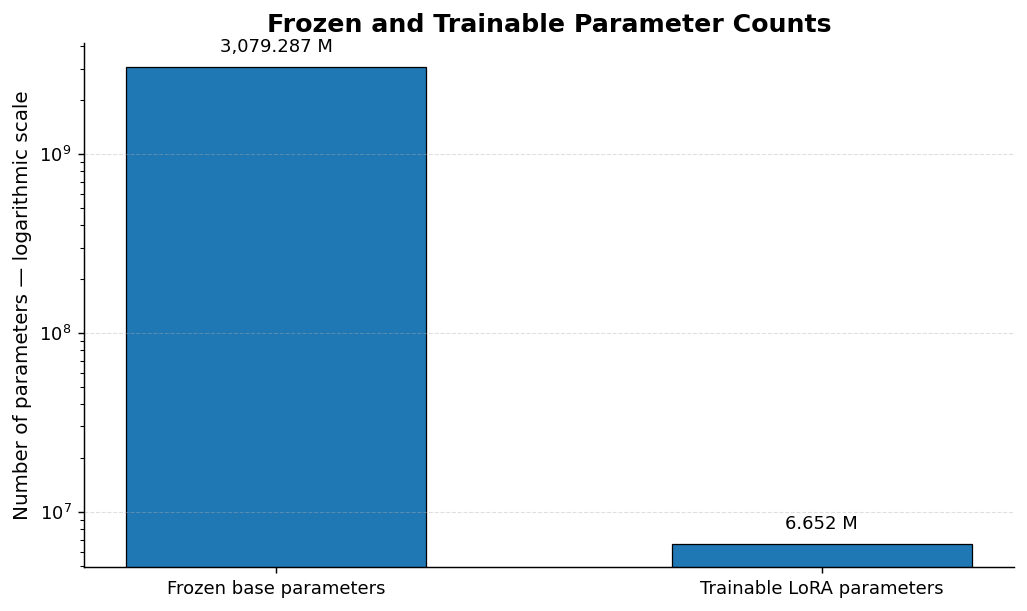

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.8))

labels = parameter_efficiency["Parameter group"]
values = parameter_efficiency["Count"]

bars = ax.bar(
    labels,
    values,
    width=0.55,
    edgecolor="black",
    linewidth=0.7,
)

for bar, value in zip(bars, values):
    ax.annotate(
        f"{value / 1e6:,.3f} M",
        (
            bar.get_x() + bar.get_width() / 2,
            value,
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

ax.set_yscale("log")
ax.set_ylabel("Number of parameters — logarithmic scale")
ax.set_title("Frozen and Trainable Parameter Counts")
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()


**Figure 1 — Parameter-efficient adaptation.** Only 6.652 million of the
model's approximately 3.086 billion parameters were trainable. A logarithmic
scale is required because the adapter represents only 0.216% of the total
parameter count.


## 4. Reproducible Training Command


```bash
python -m mlx_lm lora \
    --model Qwen/Qwen2.5-3B-Instruct \
    --train \
    --data data/finetuning \
    --adapter-path finetuning/finetuning-v6 \
    --iters 1000 \
    --batch-size 4 \
    --learning-rate 8e-6 \
    --val-batches 25 \
    --steps-per-eval 50 \
    --save-every 50 \
    --seed 42
```

The dataset used by this command is the cleaned corpus audited in Notebook 03.
The two invalid plans and all exact benchmark overlaps had been removed before
this training run.

**LoRA hyperparameters (not exposed as CLI flags above).** These were left at
the MLX-LM defaults during the original run and were not logged anywhere in
this notebook, which made the run harder to reproduce exactly. They are
recorded explicitly here, and should be pinned via a `--config` YAML file for
any future run:

| Parameter | Value | Source |
|---|---|---|
| `num_layers` | 16 | MLX-LM default |
| `lora_parameters.rank` | 8 | MLX-LM default |
| `lora_parameters.scale` | 20.0 | MLX-LM default |
| `lora_parameters.dropout` | 0.0 | MLX-LM default |
| `lora_parameters.keys` | `self_attn.q_proj`, `self_attn.v_proj` | MLX-LM default |


## 5. Canonical Training History

The following dictionaries were transcribed from the raw MLX-LM console output.
Validation loss was recorded at iteration 1 and every 50 iterations. Training
loss was logged every 10 iterations.


In [5]:
VALIDATION_HISTORY = {
    # Transcribed from the raw output produced by MLX-LM.
    1: 4.954,
    50: 0.731,
    100: 0.692,
    150: 0.661,
    200: 0.616,
    250: 0.574,
    300: 0.582,
    350: 0.635,
    400: 0.552,
    450: 0.542,
    500: 0.587,
    550: 0.595,
    600: 0.639,
    650: 0.545,
    700: 0.592,
    750: 0.597,
    800: 0.577,
    850: 0.567,
    900: 0.568,
    950: 0.595,
    1000: 0.571,
}

TRAINING_HISTORY = {
    # Transcribed from the raw output produced by MLX-LM.
    10: 2.782, 20: 1.345, 30: 0.990, 40: 0.783, 50: 0.646,
    60: 0.656, 70: 0.547, 80: 0.507, 90: 0.489, 100: 0.466,
    110: 0.460, 120: 0.464, 130: 0.473, 140: 0.431, 150: 0.425,
    160: 0.446, 170: 0.426, 180: 0.430, 190: 0.382, 200: 0.409,
    210: 0.351, 220: 0.358, 230: 0.420, 240: 0.358, 250: 0.362,
    260: 0.363, 270: 0.370, 280: 0.369, 290: 0.335, 300: 0.325,
    310: 0.366, 320: 0.380, 330: 0.344, 340: 0.315, 350: 0.317,
    360: 0.286, 370: 0.316, 380: 0.317, 390: 0.330, 400: 0.293,
    410: 0.304, 420: 0.352, 430: 0.294, 440: 0.300, 450: 0.340,
    460: 0.266, 470: 0.304, 480: 0.294, 490: 0.300, 500: 0.306,
    510: 0.271, 520: 0.341, 530: 0.324, 540: 0.284, 550: 0.311,
    560: 0.319, 570: 0.326, 580: 0.273, 590: 0.240, 600: 0.252,
    610: 0.251, 620: 0.224, 630: 0.252, 640: 0.233, 650: 0.251,
    660: 0.248, 670: 0.235, 680: 0.238, 690: 0.251, 700: 0.236,
    710: 0.237, 720: 0.249, 730: 0.265, 740: 0.239, 750: 0.285,
    760: 0.229, 770: 0.256, 780: 0.258, 790: 0.251, 800: 0.250,
    810: 0.237, 820: 0.254, 830: 0.227, 840: 0.237, 850: 0.256,
    860: 0.240, 870: 0.252, 880: 0.207, 890: 0.253, 900: 0.214,
    910: 0.227, 920: 0.255, 930: 0.223, 940: 0.233, 950: 0.231,
    960: 0.246, 970: 0.252, 980: 0.238, 990: 0.207, 1000: 0.236,
}

validation_history = pd.DataFrame({
    "Iteration": list(VALIDATION_HISTORY.keys()),
    "Validation loss": list(VALIDATION_HISTORY.values()),
})

training_history = pd.DataFrame({
    "Iteration": list(TRAINING_HISTORY.keys()),
    "Training loss": list(TRAINING_HISTORY.values()),
})

best_validation_row = validation_history.loc[
    validation_history["Validation loss"].idxmin()
]

assert int(best_validation_row["Iteration"]) == EXPERIMENT[
    "best_checkpoint"
]
assert np.isclose(
    float(best_validation_row["Validation loss"]),
    EXPERIMENT["best_validation_loss"],
)
assert np.isclose(
    VALIDATION_HISTORY[1000],
    EXPERIMENT["final_validation_loss"],
)

print("Training history matches the canonical experiment metadata.")
display(validation_history)


Training history matches the canonical experiment metadata.


,Iteration,Validation loss
0,1,4.954
1,50,0.731
2,100,0.692
3,150,0.661
4,200,0.616
5,250,0.574
6,300,0.582
7,350,0.635
8,400,0.552
9,450,0.542


## 6. Validation-Loss Trajectory


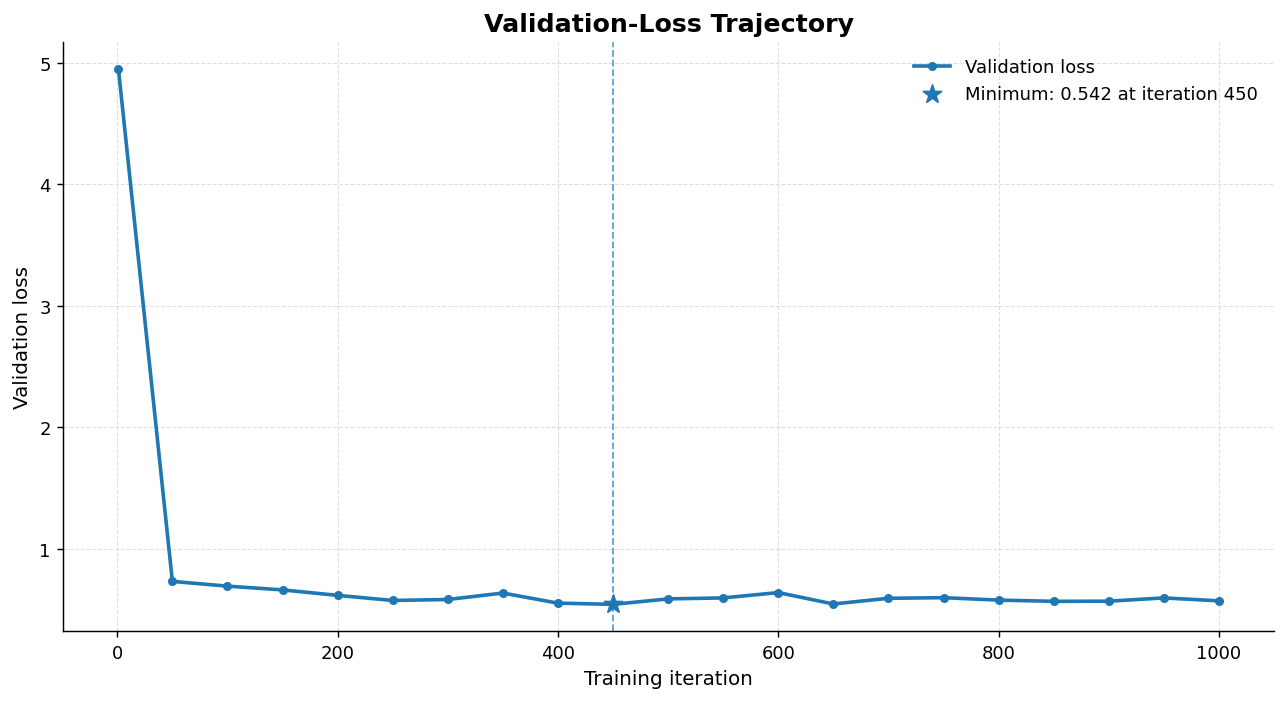

Best validation loss: 0.542
Best validation checkpoint: 450


In [6]:
best_iteration = int(best_validation_row["Iteration"])
best_loss = float(best_validation_row["Validation loss"])

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    validation_history["Iteration"],
    validation_history["Validation loss"],
    marker="o",
    linewidth=2,
    markersize=4,
    label="Validation loss",
)

ax.scatter(
    [best_iteration],
    [best_loss],
    s=110,
    marker="*",
    zorder=4,
    label=f"Minimum: {best_loss:.3f} at iteration {best_iteration}",
)

ax.axvline(
    best_iteration,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_xlabel("Training iteration")
ax.set_ylabel("Validation loss")
ax.set_title("Validation-Loss Trajectory")
ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Best validation loss: {best_loss:.3f}")
print(f"Best validation checkpoint: {best_iteration}")


**Figure 2 — Validation-loss trajectory.** Validation loss decreased rapidly
during the first 250 iterations, then oscillated around a narrower range. The
minimum recorded value was **0.542 at iteration 450**.

Later checkpoints did not improve this minimum:

- iteration 650: 0.545;
- iteration 850: 0.567;
- iteration 1,000: 0.571.

The final checkpoint was therefore not selected solely because it was the last
one written.


## 7. Training and Validation Dynamics


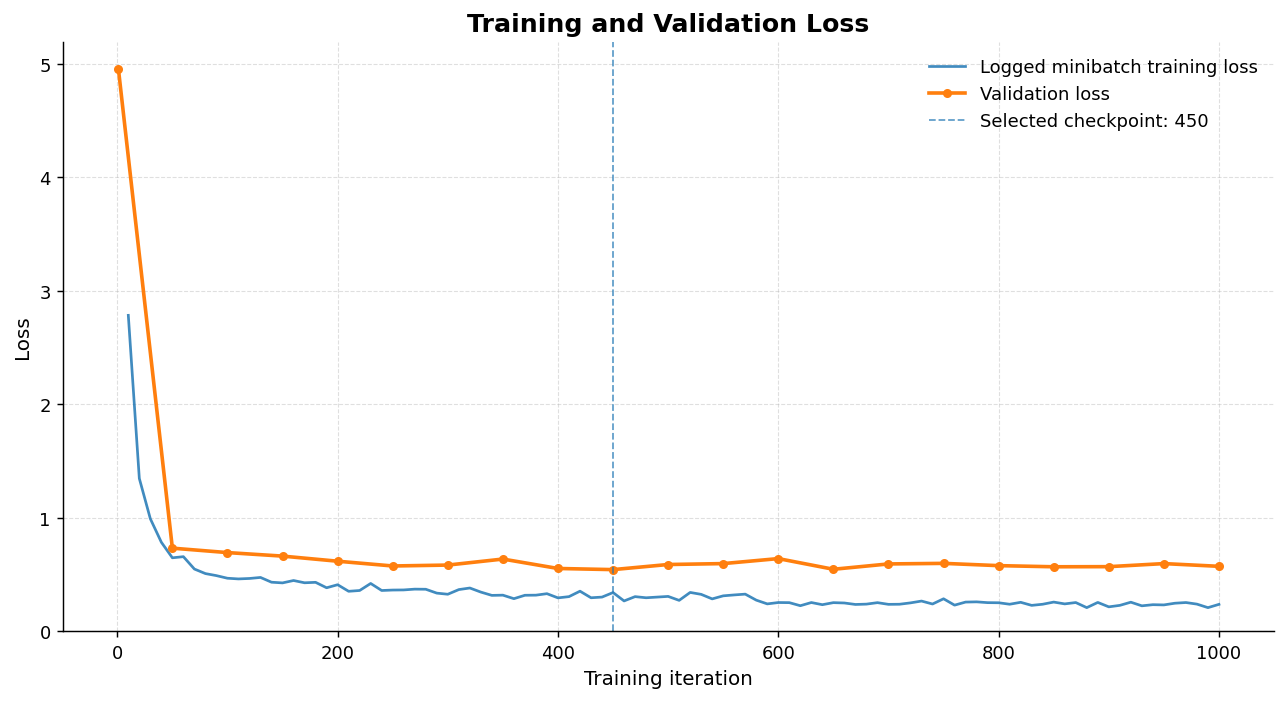

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    training_history["Iteration"],
    training_history["Training loss"],
    linewidth=1.5,
    alpha=0.85,
    label="Logged minibatch training loss",
)

ax.plot(
    validation_history["Iteration"],
    validation_history["Validation loss"],
    marker="o",
    linewidth=2,
    markersize=4,
    label="Validation loss",
)

ax.axvline(
    best_iteration,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label=f"Selected checkpoint: {best_iteration}",
)

ax.set_xlabel("Training iteration")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.set_ylim(bottom=0)
ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)
ax.legend()

plt.tight_layout()
plt.show()


**Figure 3 — Training and validation dynamics.** Training loss continued to
decrease after iteration 450, while validation loss oscillated and never
improved beyond 0.542.

The training series contains periodically logged minibatch losses, whereas
validation loss is aggregated over 25 validation batches. The curves are
therefore not directly equivalent epoch-level estimates.

The pattern nevertheless indicates diminishing generalization returns after
the selected checkpoint: additional optimization improved the training
objective without consistently improving validation behavior.


In [8]:
validation_analysis = validation_history.copy()

validation_analysis["Change from previous evaluation"] = (
    validation_analysis["Validation loss"].diff()
)

validation_analysis["Improvement from iteration 1 (%)"] = (
    (
        validation_analysis.loc[0, "Validation loss"]
        - validation_analysis["Validation loss"]
    )
    / validation_analysis.loc[0, "Validation loss"]
    * 100
)

display(
    validation_analysis.style
    .format({
        "Validation loss": "{:.3f}",
        "Change from previous evaluation": "{:+.3f}",
        "Improvement from iteration 1 (%)": "{:.1f}%",
    })
    .hide(axis="index")
)


Iteration,Validation loss,Change from previous evaluation,Improvement from iteration 1 (%)
1,4.954,+nan,0.0%
50,0.731,-4.223,85.2%
100,0.692,-0.039,86.0%
150,0.661,-0.031,86.7%
200,0.616,-0.045,87.6%
250,0.574,-0.042,88.4%
300,0.582,+0.008,88.3%
350,0.635,+0.053,87.2%
400,0.552,-0.083,88.9%
450,0.542,-0.010,89.1%


## 8. Benchmark-Based Checkpoint Selection

Validation loss identifies the strongest statistical candidate, but AXION is a
behavioral routing system. Checkpoints 450, 650 and 850 were therefore evaluated
with both `benchmark.py` and `benchmark_multistep.py`.

**Inference backend for candidate checkpoints.** Each of the three candidate
checkpoints was fused with the base model, converted to GGUF and quantized to
Q6_K — the same conversion pipeline detailed in Section 13 — then served through
the same `llama-server` instance used to benchmark the raw baseline (Notebook 01)
and the prompt-engineered base model (Notebook 02). The full sequence
(train → fuse → convert → quantize → serve → benchmark) was repeated once per
candidate rather than run only once for a single final artifact, so no checkpoint
is benchmarked through a different runtime, precision or serving stack than the
others. The comparison below therefore isolates the effect of the LoRA weights
themselves rather than differences in the inference backend.

The dictionary below is transcribed from the raw benchmark outputs.


In [9]:
CHECKPOINT_RESULTS = {
    # Transcribed from the raw outputs produced by benchmark.py
    # and benchmark_multistep.py.
    450: {
        "validation_loss": 0.542,
        "category_accuracy": 94,
        "tool_accuracy": 92,
        "parameter_accuracy": 93,
        "strict_pass_rate": 89,
        "application_success": 89,
        "multi_step_accuracy": 92,
        "tool_order_accuracy": 86,
        "no_extra_tools_accuracy": 86,
        "final_accuracy": 98,
        "loop_completion_accuracy": 86,
        "multi_step_latency_seconds": 1.14,
    },
    650: {
        "validation_loss": 0.545,
        "strict_pass_rate": 90,
        "application_success": 90,
        "multi_step_accuracy": 86,
        "tool_order_accuracy": 72,
        "no_extra_tools_accuracy": 72,
        "final_accuracy": 94,
        "loop_completion_accuracy": 72,
        "multi_step_latency_seconds": 1.09,
    },
    850: {
        "validation_loss": 0.567,
        "strict_pass_rate": 91,
        "application_success": 91,
        "multi_step_accuracy": 85,
        "tool_order_accuracy": 70,
        "no_extra_tools_accuracy": 70,
        "final_accuracy": 94,
        "loop_completion_accuracy": 70,
        "multi_step_latency_seconds": 1.07,
    },
}

checkpoint_rows = []

for checkpoint, metrics in CHECKPOINT_RESULTS.items():
    checkpoint_rows.append({
        "Checkpoint": checkpoint,
        "Validation loss": metrics["validation_loss"],
        "Strict single-step (%)": metrics["strict_pass_rate"],
        "Application success (%)": metrics["application_success"],
        "Multi-step accuracy (%)": metrics["multi_step_accuracy"],
        "Tool-order accuracy (%)": metrics["tool_order_accuracy"],
        "No-extra-tools accuracy (%)": metrics["no_extra_tools_accuracy"],
        "Final accuracy (%)": metrics["final_accuracy"],
        "Loop-completion accuracy (%)": metrics["loop_completion_accuracy"],
        "Multi-step latency (s)": metrics["multi_step_latency_seconds"],
    })

checkpoint_comparison = pd.DataFrame(checkpoint_rows)

display(
    checkpoint_comparison.style
    .format({
        "Validation loss": "{:.3f}",
        "Strict single-step (%)": "{:.0f}%",
        "Application success (%)": "{:.0f}%",
        "Multi-step accuracy (%)": "{:.0f}%",
        "Tool-order accuracy (%)": "{:.0f}%",
        "No-extra-tools accuracy (%)": "{:.0f}%",
        "Final accuracy (%)": "{:.0f}%",
        "Loop-completion accuracy (%)": "{:.0f}%",
        "Multi-step latency (s)": "{:.2f}",
    })
    .hide(axis="index")
)


Checkpoint,Validation loss,Strict single-step (%),Application success (%),Multi-step accuracy (%),Tool-order accuracy (%),No-extra-tools accuracy (%),Final accuracy (%),Loop-completion accuracy (%),Multi-step latency (s)
450,0.542,89%,89%,92%,86%,86%,98%,86%,1.14
650,0.545,90%,90%,86%,72%,72%,94%,72%,1.09
850,0.567,91%,91%,85%,70%,70%,94%,70%,1.07


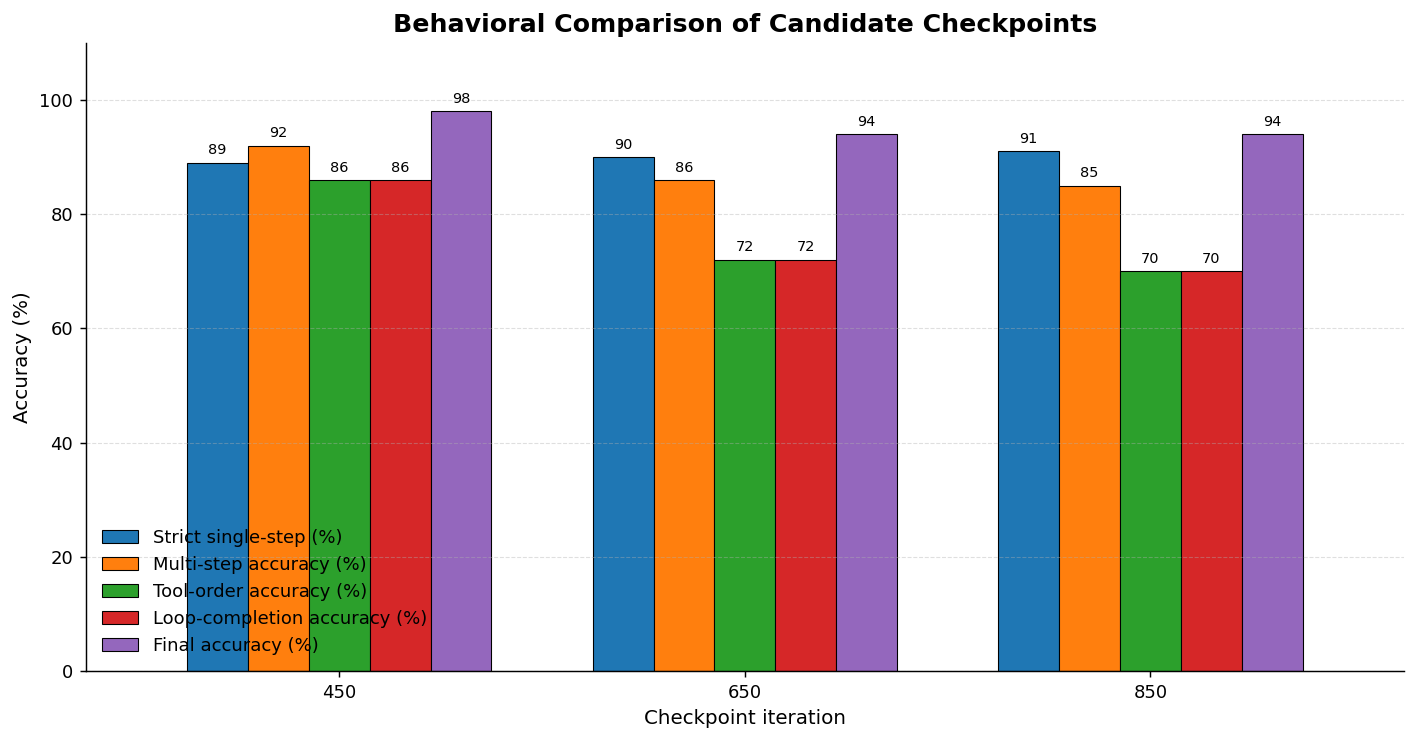

In [10]:
checkpoint_metrics = [
    "Strict single-step (%)",
    "Multi-step accuracy (%)",
    "Tool-order accuracy (%)",
    "Loop-completion accuracy (%)",
    "Final accuracy (%)",
]

checkpoint_plot = checkpoint_comparison.set_index(
    "Checkpoint"
)[checkpoint_metrics]

ax = checkpoint_plot.plot(
    kind="bar",
    figsize=(11, 5.8),
    width=0.75,
    edgecolor="black",
    linewidth=0.6,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8,
    )

ax.set_xlabel("Checkpoint iteration")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Behavioral Comparison of Candidate Checkpoints")
ax.set_ylim(0, 110)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)
ax.legend(loc="lower left")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Figure 4 — Candidate checkpoint comparison.** Later checkpoints gained one
or two points in strict single-step accuracy, but their multi-step behavior
degraded sharply.

Compared with checkpoint 450:

- checkpoint 650 gained 1 strict-pass point but lost 14 points in tool order and
  loop completion;
- checkpoint 850 gained 2 strict-pass points but lost 16 points in tool order
  and loop completion.

For AXION, sacrificing reliable sequential execution for a marginal gain on
isolated commands is not a favorable trade-off.


In [11]:
CHECKPOINT_SELECTION = {
    # Derived from the canonical validation and benchmark outputs.
    "selected_checkpoint": 450,
    "selection_reasons": [
        "lowest validation loss",
        "highest multi-step accuracy",
        "highest tool-order accuracy",
        "highest no-extra-tools accuracy",
        "highest loop-completion accuracy",
        "highest final accuracy among tested checkpoints",
    ],
}

assert (
    CHECKPOINT_SELECTION["selected_checkpoint"]
    == EXPERIMENT["best_checkpoint"]
)

selected_checkpoint = checkpoint_comparison[
    checkpoint_comparison["Checkpoint"]
    == CHECKPOINT_SELECTION["selected_checkpoint"]
]

display(selected_checkpoint.style.hide(axis="index"))

print("Selected checkpoint:", CHECKPOINT_SELECTION["selected_checkpoint"])
for reason in CHECKPOINT_SELECTION["selection_reasons"]:
    print("-", reason)


Checkpoint,Validation loss,Strict single-step (%),Application success (%),Multi-step accuracy (%),Tool-order accuracy (%),No-extra-tools accuracy (%),Final accuracy (%),Loop-completion accuracy (%),Multi-step latency (s)
450,0.542000,89,89,92,86,86,98,86,1.140000


Selected checkpoint: 450
- lowest validation loss
- highest multi-step accuracy
- highest tool-order accuracy
- highest no-extra-tools accuracy
- highest loop-completion accuracy
- highest final accuracy among tested checkpoints


## 9. Checkpoint Decision

Checkpoint **450** is retained as the final adapter candidate.

The decision is supported by two independent signals:

1. it achieved the minimum validation loss, 0.542;
2. it achieved the strongest multi-step behavior among the tested checkpoints.

This is more defensible than selecting checkpoint 850 solely because it
obtained the highest single-step strict score. AXION is an agentic system, so
tool ordering, redundant-action avoidance and loop completion are first-class
requirements.


## 10. Adapter Artifacts and Reproducibility


In [12]:
ADAPTER_DIRECTORY = Path(EXPERIMENT["adapter_directory"])

expected_checkpoints = [
    ADAPTER_DIRECTORY / f"{iteration:07d}_adapters.safetensors"
    for iteration in range(50, 1001, 50)
]

artifact_rows = []

for path in expected_checkpoints:
    artifact_rows.append({
        "Artifact": path.name,
        "Exists": path.exists(),
        "Size (MB)": (
            path.stat().st_size / 1024**2
            if path.exists()
            else np.nan
        ),
    })

artifacts_df = pd.DataFrame(artifact_rows)

display(
    artifacts_df.style
    .format({"Size (MB)": "{:.2f}"})
    .hide(axis="index")
)


Artifact,Exists,Size (MB)
0000050_adapters.safetensors,True,25.40
0000100_adapters.safetensors,True,25.40
0000150_adapters.safetensors,True,25.40
0000200_adapters.safetensors,True,25.40
0000250_adapters.safetensors,True,25.40
0000300_adapters.safetensors,True,25.40
0000350_adapters.safetensors,True,25.40
0000400_adapters.safetensors,True,25.40
0000450_adapters.safetensors,True,25.40
0000500_adapters.safetensors,True,25.40


In [13]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


selected_adapter_path = (
    ADAPTER_DIRECTORY
    / "0000450_adapters.safetensors"
)

if selected_adapter_path.exists():
    selected_adapter_sha256 = sha256_file(
        selected_adapter_path
    )

    print("Selected adapter:", selected_adapter_path)
    print(
        "Size:",
        f"{selected_adapter_path.stat().st_size / 1024**2:.2f} MB",
    )
    print("SHA-256:", selected_adapter_sha256)
else:
    selected_adapter_sha256 = None
    print(
        "Selected checkpoint not found at:",
        selected_adapter_path,
    )


Selected adapter: ../finetuning/finetuning-v6/0000450_adapters.safetensors
Size: 25.40 MB
SHA-256: 21ce0837b0eb2d2f605dbe60b96ad8c6525a74746ae6329300076e14107e5929


The selected adapter hash should be copied into the project release manifest
after the final artifact is frozen. The notebook deliberately calculates the
hash from the local checkpoint rather than inventing or duplicating it.


**Relationship to the benchmarked artifact.** The hash above identifies the
raw LoRA adapter (`.safetensors`) produced directly by MLX-LM, which is the
artifact that determines training reproducibility and is referenced in the
experiment manifest. The GGUF/Q6_K artifact actually served through
`llama-server` and benchmarked in Section 8 is a deterministic derivative of
this adapter (fuse → convert → quantize). Pinning the adapter hash is therefore
sufficient to reproduce the benchmarked artifact bit-for-bit, given the same
conversion toolchain and version.


## 11. Learning-Rate Ablation

Section 4 uses a learning rate of `8e-6`, close to MLX-LM's own default of
`1e-5` but not accompanied, in the original run, by any comparison against a
higher value. To check whether this choice was a limiting factor rather than
a deliberate one, a second run (`finetuning-v7`) was trained identically
except for the learning rate, raised to `1e-4` (12x higher), and
`val_batches`, raised from 25 to 50 to reduce noise in the reported validation
loss.

```bash
python -m mlx_lm lora \
    --model Qwen/Qwen2.5-3B-Instruct \
    --train \
    --data data/finetuning \
    --adapter-path finetuning/finetuning-v7 \
    --iters 1000 \
    --batch-size 4 \
    --learning-rate 1e-4 \
    --val-batches 50 \
    --steps-per-eval 50 \
    --save-every 50 \
    --seed 42
```


In [14]:
VALIDATION_HISTORY_V7 = {
    # Transcribed from the raw output produced by MLX-LM (finetuning-v7,
    # learning_rate=1e-4, val_batches=50).
    1: 5.076,
    50: 0.734,
    100: 0.665,
    150: 0.654,
    200: 0.631,
    250: 0.623,
    300: 0.620,
    350: 0.632,
    400: 0.579,
    450: 0.629,
    500: 0.601,
    550: 0.626,
    600: 0.631,
    650: 0.577,
    700: 0.625,
    750: 0.626,
    800: 0.592,
    850: 0.616,
    900: 0.602,
    950: 0.618,
    1000: 0.597,
}

TRAINING_HISTORY_V7 = {
    # Transcribed from the raw output produced by MLX-LM (finetuning-v7).
    10: 2.485, 20: 1.132, 30: 0.752, 40: 0.672, 50: 0.580,
    60: 0.612, 70: 0.513, 80: 0.508, 90: 0.483, 100: 0.456,
    110: 0.443, 120: 0.440, 130: 0.456, 140: 0.424, 150: 0.425,
    160: 0.431, 170: 0.427, 180: 0.435, 190: 0.388, 200: 0.418,
    210: 0.342, 220: 0.367, 230: 0.437, 240: 0.366, 250: 0.386,
    260: 0.366, 270: 0.393, 280: 0.380, 290: 0.355, 300: 0.330,
    310: 0.378, 320: 0.387, 330: 0.360, 340: 0.327, 350: 0.319,
    360: 0.307, 370: 0.327, 380: 0.332, 390: 0.336, 400: 0.308,
    410: 0.321, 420: 0.386, 430: 0.310, 440: 0.329, 450: 0.358,
    460: 0.287, 470: 0.317, 480: 0.323, 490: 0.323, 500: 0.321,
    510: 0.289, 520: 0.353, 530: 0.344, 540: 0.315, 550: 0.333,
    560: 0.353, 570: 0.349, 580: 0.296, 590: 0.272, 600: 0.273,
    610: 0.275, 620: 0.239, 630: 0.282, 640: 0.264, 650: 0.271,
    660: 0.271, 670: 0.254, 680: 0.261, 690: 0.274, 700: 0.255,
    710: 0.261, 720: 0.267, 730: 0.286, 740: 0.258, 750: 0.315,
    760: 0.263, 770: 0.283, 780: 0.282, 790: 0.273, 800: 0.281,
    810: 0.256, 820: 0.280, 830: 0.252, 840: 0.265, 850: 0.299,
    860: 0.263, 870: 0.280, 880: 0.231, 890: 0.288, 900: 0.246,
    910: 0.261, 920: 0.283, 930: 0.246, 940: 0.258, 950: 0.262,
    960: 0.272, 970: 0.288, 980: 0.263, 990: 0.234, 1000: 0.269,
}

validation_history_v7 = pd.DataFrame({
    "Iteration": list(VALIDATION_HISTORY_V7.keys()),
    "Validation loss": list(VALIDATION_HISTORY_V7.values()),
})

# Exclude the iteration-1 warm-up spike, which dwarfs the rest of both
# curves and is not informative for comparing the two runs.
v6_vals = validation_history[validation_history["Iteration"] >= 50]["Validation loss"]
v7_vals = validation_history_v7[validation_history_v7["Iteration"] >= 50]["Validation loss"]

ablation_summary = pd.DataFrame({
    "Run": ["v6 (lr=8e-6, val_batches=25)", "v7 (lr=1e-4, val_batches=50)"],
    "Min validation loss": [v6_vals.min(), v7_vals.min()],
    "Mean validation loss": [v6_vals.mean(), v7_vals.mean()],
    "Std validation loss": [v6_vals.std(), v7_vals.std()],
    "Final validation loss (iter 1000)": [
        VALIDATION_HISTORY[1000], VALIDATION_HISTORY_V7[1000],
    ],
    "Checkpoints <= 0.580": [
        int((v6_vals <= 0.580).sum()), int((v7_vals <= 0.580).sum()),
    ],
})

assert v6_vals.min() < v7_vals.min(), (
    "Expected the lower learning rate (v6) to reach a lower minimum "
    "validation loss than the higher learning rate (v7)."
)

display(
    ablation_summary.style
    .format({
        "Min validation loss": "{:.3f}",
        "Mean validation loss": "{:.3f}",
        "Std validation loss": "{:.3f}",
        "Final validation loss (iter 1000)": "{:.3f}",
    })
    .hide(axis="index")
)


Run,Min validation loss,Mean validation loss,Std validation loss,Final validation loss (iter 1000),Checkpoints <= 0.580
"v6 (lr=8e-6, val_batches=25)",0.542,0.601,0.049,0.571,8
"v7 (lr=1e-4, val_batches=50)",0.577,0.624,0.034,0.597,2


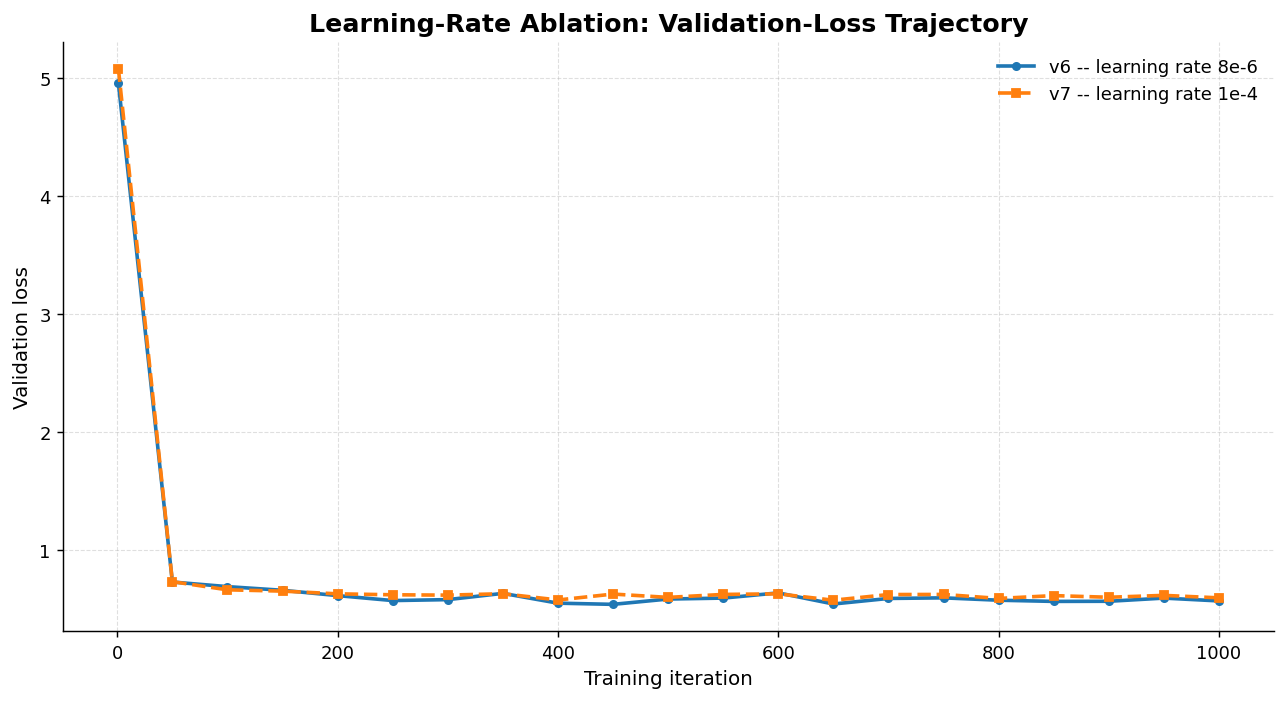

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    validation_history["Iteration"],
    validation_history["Validation loss"],
    marker="o",
    linewidth=2,
    markersize=4,
    label="v6 -- learning rate 8e-6",
)

ax.plot(
    validation_history_v7["Iteration"],
    validation_history_v7["Validation loss"],
    marker="s",
    linestyle="--",
    linewidth=2,
    markersize=4,
    label="v7 -- learning rate 1e-4",
)

ax.set_xlabel("Training iteration")
ax.set_ylabel("Validation loss")
ax.set_title("Learning-Rate Ablation: Validation-Loss Trajectory")
ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)
ax.legend()

plt.tight_layout()
plt.show()


**Figure 5 -- Learning-rate ablation.** Raising the learning rate by 12x did
not improve validation performance. The v7 run (`lr=1e-4`) converges slightly
faster in the first ~50 iterations, consistent with the larger step size, but
from there it settles into a noisier, higher plateau: its best validation
loss (0.577) is above v6's best (0.542), its mean across checkpoints is higher
(0.624 vs 0.601), and only 2 of its 20 recorded checkpoints reach 0.580 or
below, compared with 8 for v6.

Two caveats apply to this comparison. First, `val_batches` also changed
between the two runs (25 to 50); this makes v7's reported loss *more*
precise, not less, so it does not explain away v7's higher values. Second,
this is a single higher-LR data point, not an exhaustive sweep -- it does not
rule out an intermediate value performing better than both, only that the
originally suspected failure mode ("the learning rate is too low to learn
anything useful in the iteration budget") is not supported by the evidence.

**Conclusion.** The original learning rate, `8e-6`, is retained. Checkpoint
450 from `finetuning-v6` remains the selected candidate discussed in the
following sections; `finetuning-v7` is kept only as a documented negative
result for this ablation.


## 12. Training Efficiency


In [16]:
training_efficiency = pd.DataFrame({
    "Metric": [
        "Trainable parameters",
        "Trainable share",
        "Training iterations",
        "Trained tokens",
        "Average trained tokens per iteration",
        "Peak training memory",
        "Validation evaluations",
        "Saved checkpoints",
    ],
    "Value": [
        f'{EXPERIMENT["trainable_parameters"] / 1e6:.3f} M',
        f'{EXPERIMENT["trainable_percent"]:.3f}%',
        f'{EXPERIMENT["iterations"]:,}',
        f'{EXPERIMENT["trained_tokens"]:,}',
        f'{EXPERIMENT["trained_tokens"] / EXPERIMENT["iterations"]:.2f}',
        f'{EXPERIMENT["peak_training_memory_gb"]:.3f} GB',
        len(VALIDATION_HISTORY),
        EXPERIMENT["iterations"] // EXPERIMENT["save_every"],
    ],
})

display(training_efficiency.style.hide(axis="index"))


Metric,Value
Trainable parameters,6.652 M
Trainable share,0.216%
Training iterations,"1,000"
Trained tokens,"327,166"
Average trained tokens per iteration,327.17
Peak training memory,9.979 GB
Validation evaluations,21
Saved checkpoints,20


## 13. Deployment Path

Every candidate checkpoint follows the same conversion pipeline *before* it is
benchmarked, not only the checkpoint ultimately shipped:

1. train the LoRA adapter with MLX-LM;
2. fuse the adapter with the base model;
3. convert the fused model to GGUF;
4. quantize the artifact to Q6_K;
5. serve the model through `llama-server`;
6. benchmark it with `benchmark.py` and `benchmark_multistep.py` (Section 8);
7. select the checkpoint using validation loss and behavioral benchmarks;
8. consume compact JSON responses from the AXION Swift application.

Steps 2-5 were applied identically to checkpoints 450, 650 and 850, and are the
same steps used to produce the raw-baseline (Notebook 01) and prompt-engineered
(Notebook 02) artifacts. This keeps the inference backend, numeric precision and
serving stack constant across every configuration compared in this project — the
checkpoint-selection benchmark in Section 8 and the shipped production model
differ only in which adapter weights (if any) were fused before conversion, not
in how the resulting artifact was served or measured.


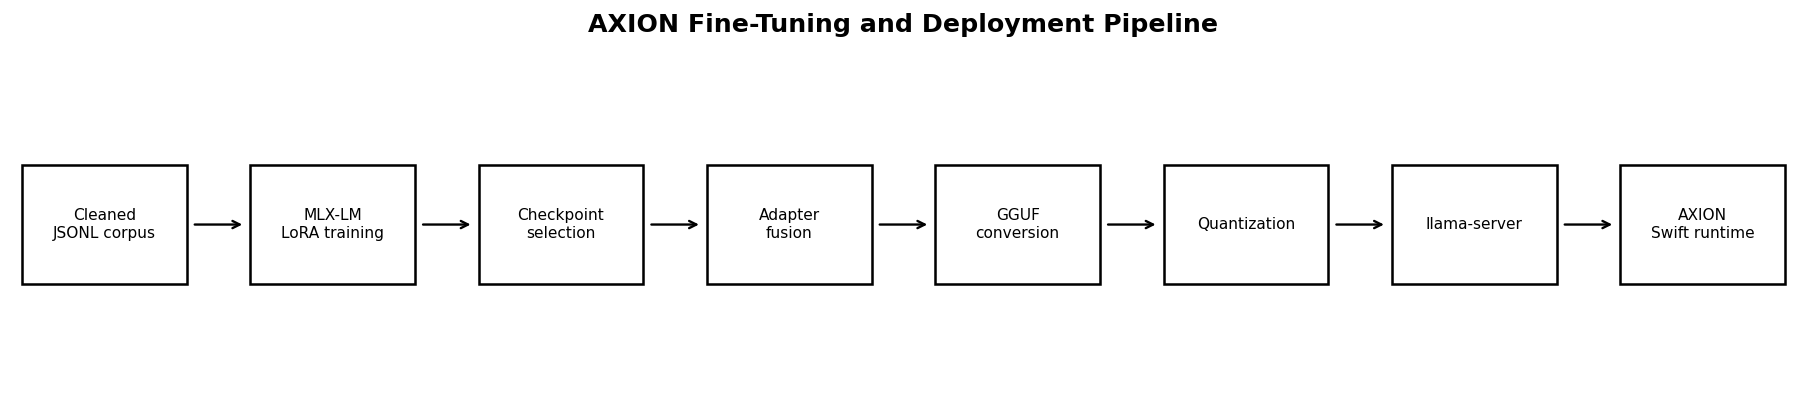

In [17]:
pipeline_steps = [
    "Cleaned\nJSONL corpus",
    "MLX-LM\nLoRA training",
    "Checkpoint\nselection",
    "Adapter\nfusion",
    "GGUF\nconversion",
    "Quantization",
    "llama-server",
    "AXION\nSwift runtime",
]

fig, ax = plt.subplots(figsize=(14, 3.2))

ax.set_xlim(-0.4, len(pipeline_steps) - 0.6)
ax.set_ylim(0, 1)
ax.axis("off")

for index, label in enumerate(pipeline_steps):
    ax.add_patch(
        plt.Rectangle(
            (index - 0.36, 0.32),
            0.72,
            0.36,
            fill=False,
            linewidth=1.4,
        )
    )

    ax.text(
        index,
        0.50,
        label,
        ha="center",
        va="center",
        fontsize=8.5,
    )

    if index < len(pipeline_steps) - 1:
        ax.annotate(
            "",
            xy=(index + 0.62, 0.50),
            xytext=(index + 0.38, 0.50),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.3,
            },
        )

ax.set_title(
    "AXION Fine-Tuning and Deployment Pipeline",
    pad=15,
)

plt.tight_layout()
plt.show()


## 14. Threats to Validity

This experiment has several limitations:

1. **Single training run**  
   Only one seed (`42`) was evaluated. Repeated runs would be required to
   quantify training variance.

2. **Single base model**  
   Results are specific to Qwen2.5-3B-Instruct and cannot be generalized to
   other architectures without additional experiments.

3. **Checkpoint evaluation scope**  
   Only checkpoints 450, 650 and 850 received the full behavioral comparison.

4. **Training-loss granularity**  
   Logged training losses represent periodic minibatches rather than
   full-epoch averages.

5. **Prompt contribution**  
   Fine-tuning is evaluated together with an explicit routing prompt. The
   adapter's isolated contribution is therefore smaller than the performance of
   the complete system.

6. **Exact benchmark separation**  
   The cleaned corpus has zero exact normalized overlap with the benchmark, but
   exact-string analysis does not eliminate every possible semantic or
   template-level similarity.

7. **Hardware specificity**  
   Memory and throughput were measured on a specific Apple Silicon
   environment.

8. **Single-point learning-rate ablation**  
   Section 11 tests one higher learning rate (`1e-4`) against the original
   value (`8e-6`), which is enough to reject the "learning rate too low"
   hypothesis but is not an exhaustive sweep. An intermediate value could
   still outperform both; this was not tested due to time constraints.


## 15. Final Training Summary


In [18]:
FINE_TUNING_SUMMARY = {
    # Transcribed or derived from the canonical outputs above.
    "experiment": "finetuning-v6",
    "training_examples": 2294,
    "validation_examples": 300,
    "iterations": 1000,
    "seed": 42,
    "trainable_parameters": "6.652 M",
    "trainable_share": "0.216%",
    "trained_tokens": "327,166",
    "peak_training_memory": "9.979 GB",
    "best_validation_loss": "0.542",
    "selected_checkpoint": "Iteration 450",
    "selected_single_step_strict": "89%",
    "selected_multi_step_accuracy": "92%",
    "selected_tool_order_accuracy": "86%",
    "selected_loop_completion_accuracy": "86%",
}

fine_tuning_summary = pd.DataFrame({
    "Metric": [
        "Experiment",
        "Training examples",
        "Validation examples",
        "Training iterations",
        "Seed",
        "Trainable parameters",
        "Trainable share",
        "Trained tokens",
        "Peak training memory",
        "Best validation loss",
        "Selected checkpoint",
        "Selected strict single-step",
        "Selected multi-step accuracy",
        "Selected tool-order accuracy",
        "Selected loop-completion accuracy",
    ],
    "Value": [
        FINE_TUNING_SUMMARY["experiment"],
        FINE_TUNING_SUMMARY["training_examples"],
        FINE_TUNING_SUMMARY["validation_examples"],
        FINE_TUNING_SUMMARY["iterations"],
        FINE_TUNING_SUMMARY["seed"],
        FINE_TUNING_SUMMARY["trainable_parameters"],
        FINE_TUNING_SUMMARY["trainable_share"],
        FINE_TUNING_SUMMARY["trained_tokens"],
        FINE_TUNING_SUMMARY["peak_training_memory"],
        FINE_TUNING_SUMMARY["best_validation_loss"],
        FINE_TUNING_SUMMARY["selected_checkpoint"],
        FINE_TUNING_SUMMARY["selected_single_step_strict"],
        FINE_TUNING_SUMMARY["selected_multi_step_accuracy"],
        FINE_TUNING_SUMMARY["selected_tool_order_accuracy"],
        FINE_TUNING_SUMMARY["selected_loop_completion_accuracy"],
    ],
})

display(fine_tuning_summary.style.hide(axis="index"))


Metric,Value
Experiment,finetuning-v6
Training examples,2294
Validation examples,300
Training iterations,1000
Seed,42
Trainable parameters,6.652 M
Trainable share,0.216%
Trained tokens,"327,166"
Peak training memory,9.979 GB
Best validation loss,0.542


## Conclusion

The cleaned dataset enabled a controlled LoRA experiment with zero exact
normalized benchmark overlap.

Training converged rapidly. The lowest validation loss, 0.542, was recorded at
iteration 450. Later checkpoints produced small gains on isolated single-step
commands but substantially degraded multi-step ordering and loop completion.

A learning-rate ablation (Section 11) tested whether a higher learning rate
(`1e-4` vs the original `8e-6`) would improve on this result. It did not: the
higher rate reached a higher minimum validation loss (0.577 vs 0.542) with
more instability across checkpoints. The original learning rate is therefore
kept, on evidence rather than by default.

Checkpoint 450 was therefore selected because it achieved both:

- the strongest validation result;
- the best overall agentic execution among the tested checkpoints.

The experiment also clarifies the role of fine-tuning in AXION. The adapter does
not replace prompt engineering. The prompt defines the routing protocol, the
LoRA adapter reinforces recurring decisions and the runtime guardrails enforce
valid execution.

Notebook 05 compares the selected checkpoint against the raw and
prompt-engineered baselines and makes the final deployment recommendation.
